# For simulated data

We take badread and simulate reads. Record how the hazard ratio changes with respect to k, and its relationship with the k-mer hit rate.

In [3]:
kvmer_results = {
    "homogeneous_random": [0.957991340465147,
0.9580352830232076,
0.9586219314566953,
0.9585138621052368,
0.9580638839898099,
0.9582327674371037,
0.9571379781420765,
0.9583110318168302,
0.9538755119771627,
0.9608021729583788],
    "heterogeneous_random": [0.9682876086407031,
0.9688755020080321,
0.9687875647668394,
0.9693008728392949,
0.9708887858924276,
0.9708229142987043,
0.9713977965883414,
0.9715921417379776,
0.9685534591194969,
0.9743205512436282],
    "homogeneous_nanopore": [0.9643250427188153,
0.9643243881790081,
0.963994773270177,
0.9655303872668933,
0.9649249802579626,
0.965593671145059,
0.9661569610716766,
0.9657268872752084,
0.9627568979221074,
0.9665185884079621],
    "heterogeneous_nanopore": [0.9717054705093716,
0.9715218410705913,
0.9729054894462287,
0.9729046415112341,
0.9744937484677617,
0.9739670336305271,
0.9750069740770971,
0.9755001695489997,
0.9727883027722256,
0.9760918359370638]
}

k = 21

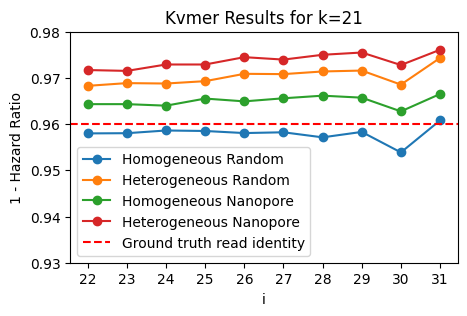

In [4]:
# Plot the change of hazard ratio with different k

import matplotlib.pyplot as plt
import numpy as np

x = k + np.arange(1, 11)
plt.figure(figsize=(5, 3))
plt.plot(x, kvmer_results["homogeneous_random"], marker='o', label='Homogeneous Random')
plt.plot(x, kvmer_results["heterogeneous_random"], marker='o', label='Heterogeneous Random')
plt.plot(x, kvmer_results["homogeneous_nanopore"], marker='o', label='Homogeneous Nanopore')
plt.plot(x, kvmer_results["heterogeneous_nanopore"], marker='o', label='Heterogeneous Nanopore')

# Also plot a horizontal line at y=0.95 for reference
plt.axhline(y=0.96, color='r', linestyle='--', label='Ground truth read identity')

plt.title(f'Kvmer Results for k={k}')
plt.xlabel('i')
plt.ylabel('1 - Hazard Ratio')
plt.ylim(0.93, 0.98)
plt.xticks(x)
plt.legend()


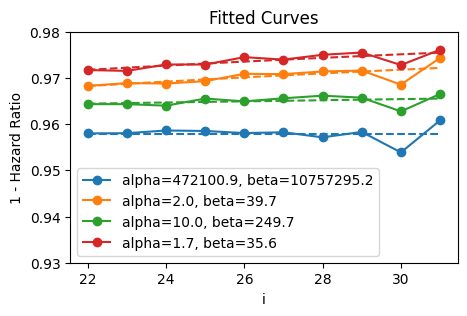

Fitted parameters for homogeneous_random: alpha = 472100.914790, beta = 10757295.235832
Fitted parameters for heterogeneous_random: alpha = 2.022498, beta = 39.656427
Fitted parameters for homogeneous_nanopore: alpha = 10.019626, beta = 249.663855
Fitted parameters for heterogeneous_nanopore: alpha = 1.673611, beta = 35.564815


In [35]:
from scipy.optimize import curve_fit

num_trim_values = 0
x = k + np.arange(1, 11)
# Define the function to fit
def fit_function(i, alpha, beta):
    return 1 - alpha / (alpha + beta + i)

# Fit the curves
fit_params = {}
for key, values in kvmer_results.items():
    i_values = x  # x is already defined as k + np.arange(1, 11)
    popt, _ = curve_fit(fit_function, i_values, values, p0=[1, 1])  # Initial guess for alpha and beta
    fit_params[key] = popt  # Store the fitted parameters

# Print the fitted parameters
# Plot the fitted curves
plt.figure(figsize=(5, 3))
i = 0
for key, values in kvmer_results.items():
    i_values = x
    fitted_curve = fit_function(i_values, *fit_params[key])
    plt.plot(i_values, fitted_curve, linestyle='--', color=f'C{i}')
    plt.plot(i_values, values, marker='o', label=f'alpha={fit_params[key][0]:.1f}, beta={fit_params[key][1]:.1f}', color=f'C{i}')
    i += 1

plt.title('Fitted Curves')
plt.xlabel('i')
plt.ylabel('1 - Hazard Ratio')
plt.legend()
plt.ylim(0.93, 0.98)
plt.show()

for key, params in fit_params.items():
    alpha, beta = params
    print(f"Fitted parameters for {key}: alpha = {alpha:.6f}, beta = {beta:.6f}")

In [36]:
for key, params in fit_params.items():
    alpha, beta = params
    print(f"Fitted parameters for {key}: mean = {alpha / (alpha + beta)}, variance = {alpha * beta / ((alpha + beta)**2 * (alpha + beta + 1))}")

Fitted parameters for homogeneous_random: mean = 0.042041522843928876, variance = 3.5864822181183297e-09
Fitted parameters for heterogeneous_random: mean = 0.04852566583165765, variance = 0.001081820274220437
Fitted parameters for homogeneous_nanopore: mean = 0.03858399481637742, variance = 0.00014230004134412863
Fitted parameters for heterogeneous_nanopore: mean = 0.04494312546165571, variance = 0.0011225158941510884


In [38]:
# Calculate the mean for each case
means = {key: np.mean(values) for key, values in kvmer_results.items()}
for key, mean in means.items():
    print(f'Mean for {key}: {mean:.6f}')

Mean for homogeneous_random: 0.957959
Mean for heterogeneous_random: 0.970283
Mean for homogeneous_nanopore: 0.964985
Mean for heterogeneous_nanopore: 0.973689


[0.9579584808999518, 0.917684454714625, 0.8791036130553231, 0.84214477158991, 0.8067397387016595, 0.7728231896699442, 0.7403325461406111, 0.7092078606636564, 0.6793917060851606, 0.6508290695893999, 0.6234672511956303, 0.597255766522264, 0.5721462536390249, 0.548092383835219, 0.525049776139476, 0.5029759154332457, 0.48183007400695793, 0.4615732364141107, 0.44216802748463524, 0.4235786433647155, 0.40577078545582385, 0.3887115971310841, 0.37236960311219813, 0.3567146513950799, 0.3417178576170453, 0.32735155176290864, 0.31358922711165504, 0.30040549132948935, 0.2877760196190246, 0.27567750983816525, 0.26408763950587577, 0.2529850246155063, 0.242349180179682, 0.2321604824339577, 0.22240013262950076, 0.2130501223479954, 0.20409320027477232, 0.19551284036885652, 0.18729321137120417, 0.17941914759486877, 0.1718761209432017, 0.16465021410445832, 0.15772809487335118, 0.15109699155217154, 0.14474466938609198, 0.13865940798917112, 0.13282997971940977, 0.12724562896295813, 0.12189605228925209, 0.11

(0.0, 100.0)

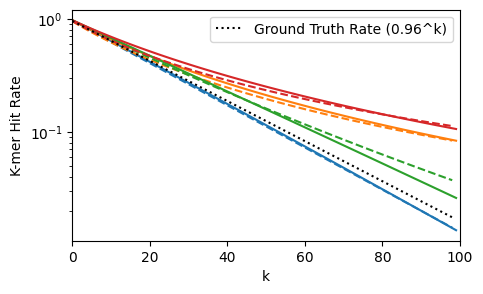

In [40]:
# Plot the k-mer hit rate and the predicted rates
import pandas as pd

kmer_hit_rate_csv = [
    "../../output/simulated_data/Ecoli_K12_MG1655_random_depth_64_id_96_homogeneous.matched_kmers.csv",
    "../../output/simulated_data/Ecoli_K12_MG1655_random_depth_64_id_96.matched_kmers.csv",
    "../../output/simulated_data/Ecoli_K12_MG1655_random_depth_64_id_96_homogeneous_nanopore.matched_kmers.csv",
    "../../output/simulated_data/Ecoli_K12_MG1655_random_depth_64_id_96_nanopore.matched_kmers.csv",
]
predicted_rates = [0.957959, 0.970283, 0.964985, 0.973689]
labels = [
    "Homogeneous Random",
    "Heterogeneous Random",
    "Homogeneous Nanopore",
    "Heterogeneous Nanopore",
]

plt.figure(figsize=(5, 3))


for i in range(len(kmer_hit_rate_csv)):
    kmer_hit_rate_df = pd.read_csv(kmer_hit_rate_csv[i])
    kmer_hit_rates = kmer_hit_rate_df['num_kmer_hit'].values
    plt.plot(kmer_hit_rates, color=f'C{i}')

    # predicted rate line
    #predicted_hit_rates = predicted_rates[i] ** np.arange(1, len(kmer_hit_rates) + 1)
    #plt.plot(predicted_hit_rates, linestyle='--', label=f'{labels[i]} Predicted Rate', color=f'C{i}')

    params = fit_params[list(kvmer_results.keys())[i]]
    alpha, beta = params
    predicted_rates = []
    for j in range(1, len(kmer_hit_rates)):
        rate = 1 - alpha / (alpha + beta + j)
        if len(predicted_rates) == 0:
            predicted_rates.append(rate)
        else:
            predicted_rates.append(predicted_rates[-1] * rate)
    print(predicted_rates)
    plt.plot(predicted_rates, linestyle='--', color=f'C{i}')


# also plot a line 0.96 ** k for reference
plt.plot(0.96 ** np.arange(1, len(predicted_rates) + 1), color='k', linestyle=':', label='Ground Truth Rate (0.96^k)')

plt.ylabel('K-mer Hit Rate')
plt.xlabel('k')
plt.yscale('log')
plt.legend()
plt.xlim(0, 100)


In [9]:
len(predicted_rates)

99

# For real data

In [17]:
kvmer_results_with_reference = {
    "ERR3152366": [
        0.9488160285031892,
0.9513522166782097,
0.9506263065396683,
0.9507804517027733,
0.95071898683373,
0.952689482419854,
0.9506252174500059,
0.9499507687853614
    ],
    "ERR2935851": [
        0.9968654662741705,
0.9969280364832004,
0.9969245010221599,
0.9969100557533418,
0.9970402129733851,
0.9969827982843921,
0.9969699152656839,
0.9969652219858829
    ],
    "SRR7415629": [
        0.8709636705103092,
0.8719430548873445,
0.8724347681568888,
0.8736169953366454,
0.8757784561709551,
0.8732869890845351,
0.8723498888065233,
0.8717120744653035
    ]
}

In [46]:
kvmer_results_without_reference = {
    "ERR3152366": [
        0.9400003255935495,
0.9468985957488596,
0.9483031475626089,
0.9504484352189763,
0.9511072878195201,
0.9526514468316107,
0.9522470697296405,
0.9524957549991356
    ],
    "ERR2935851": [
        0.9962360386810292,
0.9968025414638172,
0.9968153862517284,
0.9968324911427558,
0.9969563487421811,
0.9969186357074373,
0.996896197317835,
0.996920019749417
    ],
    "SRR7415629": [
        0.8742048065029157,
0.8760643808272481,
0.8770405514536225,
0.8784560365026514,
0.8818635295879309,
0.8812879398904784,
0.8813612388911635,
0.8807350730974177
    ]
}

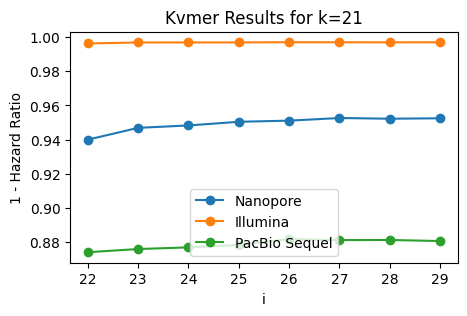

In [47]:
# Plot the change of hazard ratio with different k

import matplotlib.pyplot as plt
import numpy as np
data = kvmer_results_without_reference
x = k + np.arange(1, len(data["ERR3152366"]) + 1)

plt.figure(figsize=(5, 3))
plt.plot(x, data["ERR3152366"], marker='o', label='Nanopore')
plt.plot(x, data["ERR2935851"], marker='o', label='Illumina')
plt.plot(x, data["SRR7415629"], marker='o', label='PacBio Sequel')


plt.title(f'Kvmer Results for k={k}')
plt.xlabel('i')
plt.ylabel('1 - Hazard Ratio')
#plt.ylim(0.93, 0.)
plt.xticks(x)
plt.legend()


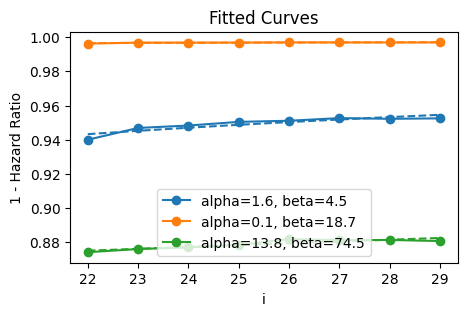

Fitted parameters for ERR3152366: alpha = 1.596410, beta = 4.542880
Fitted parameters for ERR2935851: alpha = 0.141760, beta = 18.742077
Fitted parameters for SRR7415629: alpha = 13.769049, beta = 74.455373


In [48]:
from scipy.optimize import curve_fit

# Define the function to fit
def fit_function(i, alpha, beta):
    return 1 - alpha / (alpha + beta + i)

# Fit the curves
fit_params = {}
for key, values in data.items():
    i_values = x  # x is already defined as k + np.arange(1, 11)
    popt, _ = curve_fit(fit_function, i_values, values, p0=[1, 1])  # Initial guess for alpha and beta
    fit_params[key] = popt  # Store the fitted parameters

# Print the fitted parameters
# Plot the fitted curves
plt.figure(figsize=(5, 3))
i = 0
for key, values in data.items():
    i_values = x
    fitted_curve = fit_function(i_values, *fit_params[key])
    plt.plot(i_values, fitted_curve, linestyle='--', color=f'C{i}')
    plt.plot(i_values, values, marker='o', label=f'alpha={fit_params[key][0]:.1f}, beta={fit_params[key][1]:.1f}', color=f'C{i}')
    i += 1

plt.title('Fitted Curves')
plt.xlabel('i')
plt.ylabel('1 - Hazard Ratio')
plt.legend()
#plt.ylim(0.93, 0.98)
plt.show()

for key, params in fit_params.items():
    alpha, beta = params
    print(f"Fitted parameters for {key}: alpha = {alpha:.6f}, beta = {beta:.6f}")

In [49]:
for key, params in fit_params.items():
    alpha, beta = params
    print(f"Fitted parameters for {key}: mean = {alpha / (alpha + beta)}, variance = {alpha * beta / ((alpha + beta)**2 * (alpha + beta + 1))}")

Fitted parameters for ERR3152366: mean = 0.2600317285240762, variance = 0.02695158941140845
Fitted parameters for ERR2935851: mean = 0.007506973435254094, variance = 0.00037470728142258505
Fitted parameters for SRR7415629: mean = 0.1560684513436434, variance = 0.0014761775563374927


[0.8456807160606179, 0.7166223204882276, 0.6084582174160829, 0.5176157835286916, 0.4411650328560374, 0.37669742680845536, 0.3222285711549336, 0.27611989243651086, 0.2370154346467481, 0.20379073301248288, 0.17551135868512857, 0.15139922677648213, 0.13080515156404862, 0.11318644073384083, 0.09808856360823438, 0.08513012061475303, 0.07399049377481177, 0.06439967925734051, 0.05612989968831333, 0.04898867111320849, 0.04281306132782978, 0.037464925902343786, 0.0328269481231639, 0.02879934123741627, 0.02529709736157789, 0.022247688442026257, 0.019589141708974606, 0.017268425924804674, 0.015240096013575163, 0.013465152866164936, 0.011910082641971345, 0.010546046051728163, 0.009348193162806467, 0.008295083424508486, 0.007368194032778681, 0.006551502576015416, 0.005831132235303322, 0.00519504974190205, 0.004632807894188151, 0.004135325764079481, 0.0036947008271185273, 0.0033040481699625874, 0.0029573626960509277, 0.002649400890960959, 0.0023755792450092334, 0.0021318868797591695, 0.0019148103019

/tmp/ipykernel_3750/881900453.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


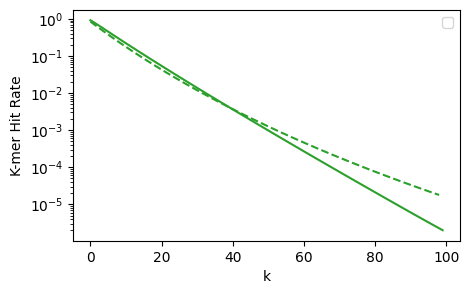

In [52]:
# Plot the k-mer hit rate and the predicted rates
import pandas as pd

kmer_hit_rate_csv = [
    "../../output/zymo/ERR3152366.matched_kmers.csv",
    "../../output/zymo/ERR2935851_ref.matched_kmers.csv",
    "../../output/zymo/SRR7415629_ref.matched_kmers.csv",
]
predicted_rates = [0.957959, 0.970283, 0.964985, 0.973689]
labels = [
    "Nanopore",
    "Illumina",
    "PacBio Sequel",
]

plt.figure(figsize=(5, 3))


for i in range(len(kmer_hit_rate_csv)):
    if i != 2:
        continue
    kmer_hit_rate_df = pd.read_csv(kmer_hit_rate_csv[i])
    kmer_hit_rates = kmer_hit_rate_df['num_kmer_hit'].values
    plt.plot(kmer_hit_rates, color=f'C{i}')

    # predicted rate line
    #predicted_hit_rates = predicted_rates[i] ** np.arange(1, len(kmer_hit_rates) + 1)
    #plt.plot(predicted_hit_rates, linestyle='--', label=f'{labels[i]} Predicted Rate', color=f'C{i}')

    params = fit_params[list(data.keys())[i]]
    alpha, beta = params
    predicted_rates = []
    for j in range(1, len(kmer_hit_rates)):
        rate = 1 - alpha / (alpha + beta + j)
        if len(predicted_rates) == 0:
            predicted_rates.append(rate)
        else:
            predicted_rates.append(predicted_rates[-1] * rate)
    print(predicted_rates)
    plt.plot(predicted_rates, linestyle='--', color=f'C{i}')


# also plot a line 0.96 ** k for reference
#plt.plot(0.96 ** np.arange(1, len(predicted_rates) + 1), color='k', linestyle=':', label='Ground Truth Rate (0.96^k)')

plt.ylabel('K-mer Hit Rate')
plt.xlabel('k')
plt.yscale('log')
plt.legend()
#plt.xlim(0, 50)


Fitted parameters: alpha = 0.079546, beta = -0.150155
Fitted parameters for mean = -1.1265799485997003, variance = -2.5777754588492754
Fitted parameters: alpha = 0.005053, beta = -0.227658
Fitted parameters for mean = -0.02270150834378312, variance = -0.02986494510609746
Fitted parameters: alpha = 0.152621, beta = -0.055702
Fitted parameters for mean = 1.574733472524578, variance = -0.8250857318154503
Fitted parameters: alpha = 0.013213, beta = -0.272914
Fitted parameters for mean = -0.05087771863003863, variance = -0.07222252987831006


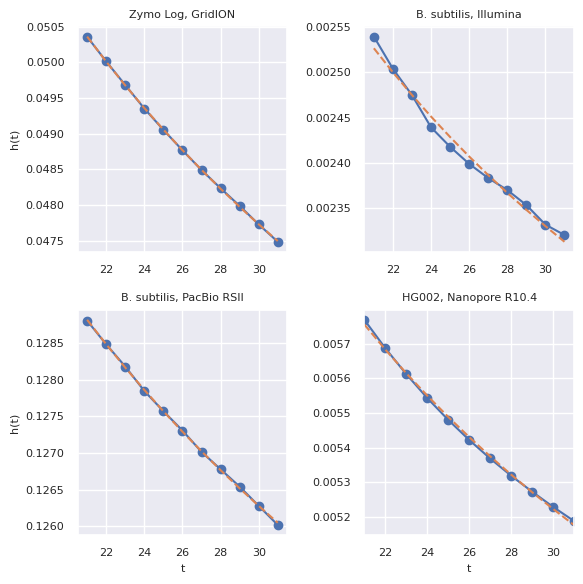

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import seaborn as sns

# Set seaborn style
sns.set(style="darkgrid")

# Define the function to fit
def fit_function_beta(i, alpha, beta):
    return alpha / (alpha + beta + i)

def fit_function_normal(i, mean, std):
    return np.exp(- mean + (i + 0.5) * (std ** 2))

def fit_function_exp(i, a, b):
    return a * (i ** b)

kmer_hit_rate_csv = [
    "../../output/zymo/ERR3152366.matched_kmers.csv",
    "../../output/zymo/ERR2935851_ref.matched_kmers.csv",
    "../../output/zymo/SRR7415629_ref.matched_kmers.csv",
    "../../output/human/HG002.bam.tmp.0000.matched_kmers.csv"
]

labels = [
    "Zymo Log, GridION",
    "B. subtilis, Illumina",
    "B. subtilis, PacBio RSII",
    "HG002, Nanopore R10.4",
]

# Plot in 3 separate figures, the hazard ratio and the predicted k-mer hit rate.
# The hazard ratio is calculated by matched_kmers(k) / matched_kmers(k-1)
font_size = 8  # Set a common font size for labels and titles
hazard_ratio_plot_range = range(21, 32)
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
axes = axes.flatten()

for i in range(len(kmer_hit_rate_csv)):
    kmer_hit_rate_df = pd.read_csv(kmer_hit_rate_csv[i])
    kmer_hit_rates = kmer_hit_rate_df['num_kmer_hit'].values

    hazard_ratios = []
    for j in hazard_ratio_plot_range:
        hazard_ratio = 1 - (kmer_hit_rates[j] / kmer_hit_rates[j - 1])
        hazard_ratios.append(hazard_ratio)
    
    # Fit the curve alpha/(alpha + beta + t) to the hazard ratios
    params, _ = curve_fit(fit_function_exp, list(hazard_ratio_plot_range), hazard_ratios, p0=[0.01, 0.01])
    alpha, bet = params
    print(f"Fitted parameters: alpha = {alpha:.6f}, beta = {bet:.6f}")

    mean = alpha / (alpha + bet)
    variance = alpha * bet / ((alpha + bet)**2 * (alpha + bet + 1))
    print(f"Fitted parameters for mean = {mean}, variance = {variance}")

    axes[i].plot(hazard_ratio_plot_range, hazard_ratios, marker='o', label='Observed Hazard Ratio', color='C0')
    fitted_hazard_ratios = [fit_function_exp(t, alpha, bet) for t in hazard_ratio_plot_range]
    axes[i].plot(hazard_ratio_plot_range, fitted_hazard_ratios, linestyle='--', label=f'Fitted Curve', color='C1')
    #axes[i].set_yscale('log')
    #axes[i].set_xscale('log')
    axes[i].tick_params(axis='both', labelsize=font_size)

    axes[i].set_title(labels[i], fontsize=font_size)
    if i >= 2:
        axes[i].set_xlabel('t', fontsize=font_size)
    if i % 2 == 0:
        axes[i].set_ylabel('h(t)', fontsize=font_size)
    #axes[i].legend()
    

plt.tight_layout()

plt.xlim(hazard_ratio_plot_range.start, hazard_ratio_plot_range.stop - 1)
plt.show()
#plt.ylim(0, 0.05)

In [19]:
0.500103 / (0.500103+65.510821)

0.007576064228399529